In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from xgboost import XGBClassifier 
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Model Training

## Day 9 Tasks (Model Training + Selection)
- Load processed train/test splits.
- Train baseline models (LR, DT, RF, KNN, XGBoost); skip SVM due to scale.
- Compare ROC-AUC and class 1 precision/recall/f1.
- Tune RF and XGBoost with GridSearchCV.
- Select best model and tune decision threshold for recall-heavy screening.

In [3]:
x_train = pd.read_csv("../data/processed/x_train_final.csv")
x_test = pd.read_csv("../data/processed/x_test_final.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
logmodel = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
logmodel.fit(x_train,y_train)
log_y_pred = logmodel.predict(x_test)
log_class_score = classification_report(y_test,log_y_pred)
log_roc_auc = roc_auc_score(y_test,logmodel.predict_proba(x_test)[:,1])

In [4]:
print(log_class_score)
print(log_roc_auc)

              precision    recall  f1-score   support

           0       0.94      0.72      0.82    343631
           1       0.32      0.74      0.44     60084

    accuracy                           0.72    403715
   macro avg       0.63      0.73      0.63    403715
weighted avg       0.85      0.72      0.76    403715

0.800893739239343


In [5]:
decmodel = DecisionTreeClassifier(max_depth=10, class_weight='balanced',random_state=42)
decmodel.fit(x_train,y_train)
dec_y_pred = decmodel.predict(x_test)
dec_class_score = classification_report(y_test,dec_y_pred)
dec_roc_auc = roc_auc_score(y_test,decmodel.predict_proba(x_test)[:,1])

In [6]:
print(dec_class_score)
print(dec_roc_auc)

              precision    recall  f1-score   support

           0       0.94      0.69      0.80    343631
           1       0.30      0.77      0.44     60084

    accuracy                           0.70    403715
   macro avg       0.62      0.73      0.62    403715
weighted avg       0.85      0.70      0.75    403715

0.8017037910512774


In [7]:
ranmodel = RandomForestClassifier(n_estimators=100,max_depth=10,class_weight='balanced',random_state=42)
ranmodel.fit(x_train,y_train)
ran_y_pred = ranmodel.predict(x_test)
ran_class_score = classification_report(y_test,ran_y_pred)
ran_roc_auc = roc_auc_score(y_test,ranmodel.predict_proba(x_test)[:,1])

In [8]:
print(ran_class_score)
print(ran_roc_auc)

              precision    recall  f1-score   support

           0       0.94      0.71      0.81    343631
           1       0.31      0.75      0.44     60084

    accuracy                           0.72    403715
   macro avg       0.63      0.73      0.63    403715
weighted avg       0.85      0.72      0.76    403715

0.804202161760918


In [ ]:
x_train_knn,y_train_knn = resample(x_train , y_train , n_samples=100000,random_state=42,stratify=y_train)
knmodel = KNeighborsClassifier(n_neighbors=5)
knmodel.fit(x_train_knn,y_train_knn)
kn_y_pred = knmodel.predict(x_test)
kn_class_score = classification_report(y_test,kn_y_pred)
kn_roc_auc = roc_auc_score(y_test,knmodel.predict_proba(x_test)[:,1])

In [ ]:
print(kn_class_score)
print(kn_roc_auc)

              precision    recall  f1-score   support

           0       0.87      0.95      0.91    343631
           1       0.41      0.18      0.25     60084

    accuracy                           0.84    403715
   macro avg       0.64      0.57      0.58    403715
weighted avg       0.80      0.84      0.81    403715

0.6892823971958201


In [4]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(scale_pos_weight)

5.719159842886626


In [11]:
xgmodel = XGBClassifier(n_estimators=100,max_depth=6,scale_pos_weight=scale_pos_weight,learning_rate=0.1,random_state=42)
xgmodel.fit(x_train,y_train)
xg_y_pred = xgmodel.predict(x_test)
xg_class_score = classification_report(y_test,xg_y_pred)
xg_roc_auc = roc_auc_score(y_test,xgmodel.predict_proba(x_test)[:,1])

In [12]:
print(xg_class_score)
print(xg_roc_auc)

              precision    recall  f1-score   support

           0       0.95      0.71      0.81    343631
           1       0.32      0.76      0.45     60084

    accuracy                           0.72    403715
   macro avg       0.63      0.74      0.63    403715
weighted avg       0.85      0.72      0.76    403715

0.8135686356671931


## Baseline Model Results (Test Set)
Class 1 metrics shown below (diabetes = 1).
| Model | ROC-AUC | Precision (1) | Recall (1) | F1 (1) |
| --- | --- | --- | --- | --- |
| Logistic Regression | 0.8009 | 0.32 | 0.74 | 0.44 |
| Decision Tree | 0.8017 | 0.30 | 0.77 | 0.44 |
| Random Forest | 0.8042 | 0.31 | 0.75 | 0.44 |
| KNN (subsampled) | 0.6893 | 0.41 | 0.18 | 0.25 |
| XGBoost | 0.8136 | 0.32 | 0.76 | 0.45 |

Notes:
- SVM skipped due to computational cost on ~2M rows.
- KNN underperformed and is not a candidate for tuning.

In [13]:
binary_cols = ["_RFBING5",'_AIDTST3','HLTHPLN1','QLACTLM2','CHCOCNCR','_RFHLTH','HAVARTH3','HIVTST6','MEDCOST','CHCSCNCR','EXERANY2','DRNKANY5','_HCVU651','ADDEPEV2','PERSDOC2','CVDSTRK3','_TOTINDA','CHCKIDNY','CVDCRHD4','CVDINFR4','SEX','_DRDXAR1','PNEUVAC3']
continous_cols = ["PHYSHLTH",'_BMI5','ALCDAY5']
ordinal_cols = ["_SMOKER3","GENHLTH",'MENTHLTH','_AGEG5YR','INCOME2','EDUCA','_ASTHMS1',"CHECKUP1",'_CHLDCNT']

## Hyperparameter Tuning for RF and XGboost

In [14]:
x_tune, _, y_tune, _ = train_test_split(
    x_train, y_train,
    train_size=100000,
    random_state=42,
    stratify=y_train
)

In [16]:
rf_param_grid = {
    'n_estimators' : [80,120],
    'max_depth' : [8,12],
    'min_samples_split': [3,8]
}
gr = GridSearchCV(estimator=ranmodel,param_grid=rf_param_grid,scoring='roc_auc',cv=3,n_jobs=-1,verbose=2)
gr.fit(x_tune,y_tune)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              max_depth=10, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [8, 12], 'min_samples_split': [3, 8],
                         'n_estimators': [80, 120]},
             scoring='roc_auc', verbose=2)

In [17]:
print(f"Best ROC-AUC(CV): {gr.best_score_:.4f}")
best_rf = gr.best_estimator_
best_rf.fit(x_train,y_train)

rf_tuned_pred = best_rf.predict(x_test)
rf_tuned_roc_auc = roc_auc_score(y_test,best_rf.predict_proba(x_test)[:,1])
print(classification_report(y_test,rf_tuned_pred))
print(f"ROC-AUC: {rf_tuned_roc_auc}")

Best ROC-AUC(CV): 0.8029
              precision    recall  f1-score   support

           0       0.94      0.72      0.82    343631
           1       0.32      0.75      0.45     60084

    accuracy                           0.72    403715
   macro avg       0.63      0.73      0.63    403715
weighted avg       0.85      0.72      0.76    403715

ROC-AUC: 0.8071152264231514


In [18]:
xg_param_grid = {
    'n_estimators': [80, 120],
    'max_depth': [4, 8],
    'learning_rate': [0.08, 0.12]
}
grxg = GridSearchCV(estimator=xgmodel,param_grid=xg_param_grid,cv=3,scoring='roc_auc',n_jobs=-1,verbose=2)
grxg.fit(x_tune,y_tune)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=6,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=100,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.08, 0.12], 'max_depth': [4, 8],
                         'n_estimators': [80, 120]},
             scoring='roc_auc', verbose=2)

In [19]:
print(f"Best ROC-AUC: {grxg.best_score_:.4f}")
best_xg = grxg.best_estimator_
best_xg.fit(x_train,y_train)

xg_tuned_pred = best_xg.predict(x_test)
xg_tuned_roc_auc = roc_auc_score(y_test,best_xg.predict_proba(x_test)[:,1])
print(classification_report(y_test,xg_tuned_pred))
print(f"ROC-AUC: {xg_tuned_roc_auc}")

Best ROC-AUC: 0.8091
              precision    recall  f1-score   support

           0       0.94      0.72      0.81    343631
           1       0.32      0.76      0.45     60084

    accuracy                           0.72    403715
   macro avg       0.63      0.74      0.63    403715
weighted avg       0.85      0.72      0.76    403715

ROC-AUC: 0.8127385298999742


## Hyperparameter Tuning Summary (RF + XGBoost)
| Model | Best CV ROC-AUC | Best Params | Tuned Test ROC-AUC | Precision (1) | Recall (1) | F1 (1) |
| --- | --- | --- | --- | --- | --- | --- |
| Random Forest | 0.8029 | n_estimators=120, max_depth=12, min_samples_split=8, class_weight=balanced, random_state=42 | 0.8071 | 0.32 | 0.75 | 0.45 |
| XGBoost | 0.8091 | n_estimators=120, max_depth=4, learning_rate=0.12 | 0.8127 | 0.32 | 0.76 | 0.45 |

Decision: XGBoost is the best overall performer based on ROC-AUC and recall.

In [20]:
print(grxg.best_params_)

{'learning_rate': 0.12, 'max_depth': 4, 'n_estimators': 120}


In [21]:
y_proba = best_xg.predict_proba(x_test)[:,1]
print(len(y_proba))

403715


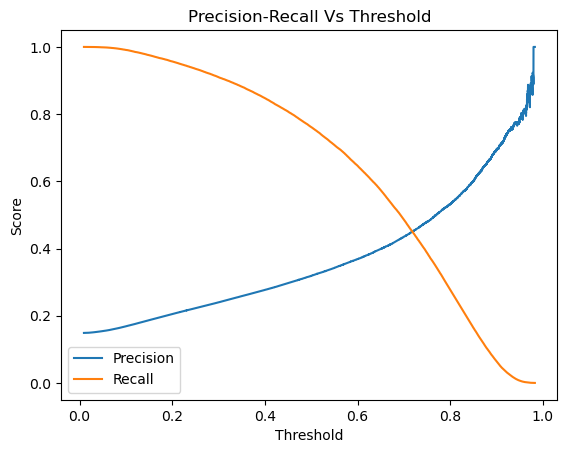

In [ ]:
precisions,recalls,thresholds = precision_recall_curve(y_test,y_proba)
plt.plot(thresholds,precisions[:-1],label="Precision")
plt.plot(thresholds,recalls[:-1],label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Vs Threshold")
plt.legend()
plt.savefig('../reports/model/threshold_tuning.png',bbox_inches='tight',dpi=150)
plt.show()

## Threshold Tuning (XGBoost)
Goal: prioritize recall for screening; false negatives are more costly than false positives.

Precision/Recall at selected thresholds (class 1):
| Threshold | Precision | Recall |
| --- | --- | --- |
| 0.30 | 0.24 | 0.91 |
| 0.35 | 0.26 | 0.88 |
| 0.40 | 0.28 | 0.85 |
| 0.45 | 0.30 | 0.81 |
| 0.50 | 0.32 | 0.76 |
| 0.55 | 0.34 | 0.71 |
| 0.60 | 0.37 | 0.65 |

Selected threshold: 0.40 (recall 0.85, precision 0.28).

Plot reference:
![Precision-Recall vs Threshold](../reports/model/threshold_tuning.png)

In [22]:
threshold = 0.35
y_pred_tuned = (y_proba>=threshold).astype(int)
print(classification_report(y_test,y_pred_tuned))

              precision    recall  f1-score   support

           0       0.96      0.56      0.71    343631
           1       0.26      0.88      0.40     60084

    accuracy                           0.61    403715
   macro avg       0.61      0.72      0.55    403715
weighted avg       0.86      0.61      0.66    403715



In [23]:
threshold = 0.3
y_pred_tuned = (y_proba>=threshold).astype(int)
print(classification_report(y_test,y_pred_tuned))

              precision    recall  f1-score   support

           0       0.97      0.50      0.66    343631
           1       0.24      0.91      0.38     60084

    accuracy                           0.56    403715
   macro avg       0.60      0.70      0.52    403715
weighted avg       0.86      0.56      0.62    403715



In [24]:
threshold = 0.4
y_pred_tuned = (y_proba>=threshold).astype(int)
print(classification_report(y_test,y_pred_tuned))

              precision    recall  f1-score   support

           0       0.96      0.61      0.75    343631
           1       0.28      0.85      0.42     60084

    accuracy                           0.65    403715
   macro avg       0.62      0.73      0.58    403715
weighted avg       0.86      0.65      0.70    403715



In [25]:
for threshold in [0.45, 0.50, 0.55, 0.60]:
    y_pred_tuned = (y_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_tuned, output_dict=True)
    print(f"Threshold {threshold}: precision={report['1']['precision']:.2f}, recall={report['1']['recall']:.2f}")

Threshold 0.45: precision=0.30, recall=0.81
Threshold 0.5: precision=0.32, recall=0.76
Threshold 0.55: precision=0.34, recall=0.71
Threshold 0.6: precision=0.37, recall=0.65


In [26]:
threshold = 0.4
y_pred_tuned = (y_proba>=threshold).astype(int)
print(classification_report(y_test,y_pred_tuned))

              precision    recall  f1-score   support

           0       0.96      0.61      0.75    343631
           1       0.28      0.85      0.42     60084

    accuracy                           0.65    403715
   macro avg       0.62      0.73      0.58    403715
weighted avg       0.86      0.65      0.70    403715



In [5]:
best_xg = XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,scale_pos_weight=scale_pos_weight,random_state=42)

In [6]:
best_xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [8]:
y_pred = best_xg.predict(x_test)
print(classification_report(y_test,y_pred))
print(roc_auc_score(y_test,best_xg.predict_proba(x_test)[0:,1]))

              precision    recall  f1-score   support

           0       0.94      0.71      0.81    343631
           1       0.31      0.76      0.44     60084

    accuracy                           0.72    403715
   macro avg       0.63      0.73      0.63    403715
weighted avg       0.85      0.72      0.75    403715

0.8068401767724731


In [9]:
import joblib
joblib.dump(best_xg, '../models/xgboost_final.pkl')

['../models/xgboost_final.pkl']

## Final Day 9 Documentation (Ready to Reuse)
Day 9: ML models trained and compared (LR, DT, RF, KNN, XGBoost). SVM skipped due to computational infeasibility on ~2M rows. XGBoost delivered the best ROC-AUC (0.8136) with strong recall for class 1, so it was selected for further tuning. RF and XGBoost were tuned with GridSearchCV; best XGBoost params were n_estimators=120, max_depth=4, learning_rate=0.12. Threshold tuning prioritized recall for screening, recognizing the 84/16 class imbalance and the higher cost of false negatives.

Final decision: use XGBoost with threshold 0.40 (recall 0.85, precision 0.28). This is appropriate for a screening tool that flags patients for further clinical testing rather than diagnosis.